In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

VIDEO_PATH = "../data/subject1/vid.avi"

# OpenCV's built-in Haar cascade face detector
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

print("OpenCV version:", cv2.__version__)
print("Face detector loaded ✓")

OpenCV version: 4.12.0
Face detector loaded ✓


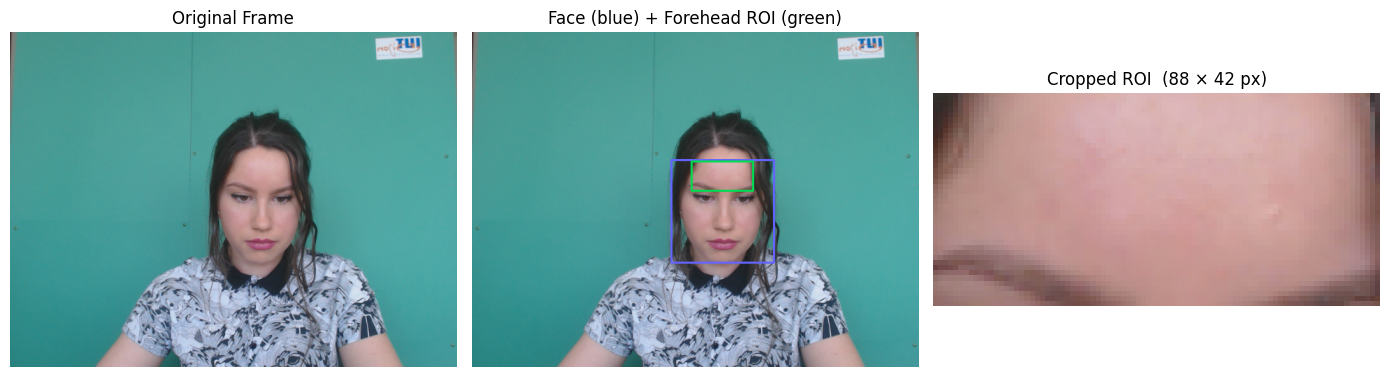

Face box : x=285, y=183, w=147, h=147
ROI box  : x1=314, y1=185, x2=402, y2=227


In [3]:
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, 100)
ret, frame = cap.read()
cap.release()

frame_rgb  = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# Detect face
faces = face_cascade.detectMultiScale(
    frame_gray, scaleFactor=1.1, minNeighbors=5, minSize=(80, 80)
)
fx, fy, fw, fh = faces[0]  # x, y, width, height of face box

# Forehead = top 30% of face, center 60% width (avoids hairline edges)
roi_x1 = fx + int(fw * 0.20)
roi_x2 = fx + int(fw * 0.80)
roi_y1 = fy + int(fh * 0.02)
roi_y2 = fy + int(fh * 0.30)

roi = frame_rgb[roi_y1:roi_y2, roi_x1:roi_x2]

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].imshow(frame_rgb)
axes[0].set_title("Original Frame")
axes[0].axis('off')

overlay = frame_rgb.copy()
cv2.rectangle(overlay, (fx, fy), (fx+fw, fy+fh), (100, 100, 255), 2)    # face box (blue)
cv2.rectangle(overlay, (roi_x1, roi_y1), (roi_x2, roi_y2), (0, 220, 80), 2)  # ROI (green)
axes[1].imshow(overlay)
axes[1].set_title("Face (blue) + Forehead ROI (green)")
axes[1].axis('off')

axes[2].imshow(roi)
axes[2].set_title(f"Cropped ROI  ({roi_x2-roi_x1} × {roi_y2-roi_y1} px)")
axes[2].axis('off')

plt.tight_layout()
plt.savefig("../outputs/roi_detection.png", dpi=150)
plt.show()
print(f"Face box : x={fx}, y={fy}, w={fw}, h={fh}")
print(f"ROI box  : x1={roi_x1}, y1={roi_y1}, x2={roi_x2}, y2={roi_y2}")

In [4]:
roi_coords = []

cap = cv2.VideoCapture(VIDEO_PATH)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

for i in range(frame_count):
    ret, frame = cap.read()
    if not ret:
        break

    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        frame_gray, scaleFactor=1.1, minNeighbors=5, minSize=(80, 80)
    )

    if len(faces) > 0:
        fx, fy, fw, fh = faces[0]
        roi_coords.append((
            fx + int(fw * 0.20), fy + int(fh * 0.02),
            fx + int(fw * 0.80), fy + int(fh * 0.30)
        ))
    else:
        roi_coords.append(roi_coords[-1] if roi_coords else (0, 0, 10, 10))

    if i % 200 == 0:
        print(f"  Processed {i}/{frame_count} frames...")

cap.release()
roi_coords = np.array(roi_coords)
np.save("../outputs/roi_coords.npy", roi_coords)
print(f"\nDone. {len(roi_coords)} frames saved → outputs/roi_coords.npy")

  Processed 0/1547 frames...
  Processed 200/1547 frames...
  Processed 400/1547 frames...
  Processed 600/1547 frames...
  Processed 800/1547 frames...
  Processed 1000/1547 frames...
  Processed 1200/1547 frames...
  Processed 1400/1547 frames...

Done. 1547 frames saved → outputs/roi_coords.npy
